<a href="https://colab.research.google.com/github/VIRULHAKA/ppg_emotion_recognition/blob/main/simple_cnn_for_emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.signal import butter, filtfilt
from google.colab import drive

drive.mount('/content/drive')
combined_PPG_data = np.load('/content/drive/MyDrive/combined_PPG_data_1001-1030.npy', allow_pickle=True) # [participant_id, esm_time, valence, arousal, physiol_data] * 764
filtered_PPG_data = np.load('/content/drive/MyDrive/butterworth_filtered_and_lms_filtered_PPG_signal_1001-1030.npy', allow_pickle=True)

Mounted at /content/drive


In [ ]:
filtered_PPG_temp = filtered_PPG_data
combined_PPG_temp = combined_PPG_data
for i in range(len(filtered_PPG_data)):
  if filtered_PPG_data[763 - i, 1] is None or len(filtered_PPG_data[763-i, 1]) < 400:
    filtered_PPG_temp = np.delete(filtered_PPG_temp, 763 - i, axis=0)
    combined_PPG_temp = np.delete(combined_PPG_temp, 763 - i, axis=0)
print(len(filtered_PPG_temp))
print(len(combined_PPG_temp))

707
707


In [ ]:
train_set = combined_PPG_temp[:624]
test_set = combined_PPG_temp[624:] # 27:3的训练集人数-测试集人数比 624:83

ppg_train = filtered_PPG_temp[:624, 1]
ppg_test = filtered_PPG_temp[624:, 1]

valence_train_temp = train_set[:, 2] - 1
valence_train = np.zeros_like(valence_train_temp)
valence_train[valence_train_temp == 2] = 1
valence_train[valence_train_temp >= 3] = 2
valence_train = valence_train.astype('int64')

arousal_train_temp = train_set[:, 3] - 1
arousal_train = np.zeros_like(arousal_train_temp)
arousal_train[arousal_train_temp == 2] = 1
arousal_train[arousal_train_temp >= 3] = 2
arousal_train = arousal_train.astype('int64')

valence_test_temp = test_set[:, 2] - 1
valence_test = np.zeros_like(valence_test_temp)
valence_test[valence_test_temp == 2] = 1
valence_test[valence_test_temp >= 3] = 2
valence_test = valence_test.astype('int64')

arousal_test_temp = test_set[:, 3] - 1
arousal_test = np.zeros_like(arousal_test_temp)
arousal_test[arousal_test_temp == 2] = 1
arousal_test[arousal_test_temp >= 3] = 2
arousal_test = arousal_test.astype('int64')

In [ ]:
print(1 / np.bincount(valence_train))
print(np.bincount(valence_test))
print(np.bincount(arousal_train))
print(np.bincount(arousal_test))

[0.00819672 0.00460829 0.00350877]
[30 12 41]
[208 216 200]
[40  7 36]


In [ ]:
def segment_ppg(ppg_signal, win=400, step=400):
  '''把ppg信号切成1200长度的窗的序列，同时返回一个计数序列，
  计数的意义是对应的valence和arousal信号需要重复的次数'''
  ppg_segments = []
  cnt_list = []
  N = len(ppg_signal)

  for i in range(N):
    cnt = 0
    if ppg_signal[i] is None:
      cnt_list.append(cnt)
      continue
    m = len(ppg_signal[i])


    for start in range(0, len(ppg_signal[i]) - win + 1, step):
        ppg_segments.append(ppg_signal[i][start:start + win])
        cnt += 1
    cnt_list.append(cnt)
  return ppg_segments, cnt_list

X_train_segmented, cnt_list_train = segment_ppg(ppg_train) # len(list)=20182, len(ndarray)=1200
X_test_segmented, cnt_list_test = segment_ppg(ppg_test)

valence_train_list = []
valence_test_list = []
arousal_train_list = []
arousal_test_list = []
for i in range(len(ppg_train)):
  for j in range(cnt_list_train[i]):
    valence_train_list.append(valence_train[i])
    arousal_train_list.append(arousal_train[i])


for i in range(len(ppg_test)):
  for j in range(cnt_list_test[i]):
    valence_test_list.append(valence_test[i])
    arousal_test_list.append(arousal_test[i])


X_train_torch = torch.tensor(X_train_segmented).float()
X_train_torch = X_train_torch.unsqueeze(1)
X_test_torch = torch.tensor(X_test_segmented).float()
X_test_torch = X_test_torch.unsqueeze(1)
valence_train_torch = torch.tensor(valence_train_list).float()
arousal_train_torch = torch.tensor(arousal_train_list).float()
valence_test_torch = torch.tensor(valence_test_list).float()
arousal_test_torch = torch.tensor(arousal_test_list).float()
valence_train_torch = valence_train_torch.long()
valence_test_torch = valence_test_torch.long()
arousal_train_torch = arousal_train_torch.long()
arousal_test_torch = arousal_test_torch.long()

/tmp/ipykernel_1032/881939522.py:41: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X_train_torch = torch.tensor(X_train_segmented).float()


In [ ]:
class cnnModel(nn.Module):
  def __init__(self,num_emotions):
      super().__init__()

      self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, padding=2)
      self.bn1 = nn.BatchNorm1d(16)

      self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
      self.bn2 = nn.BatchNorm1d(32)

      self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
      self.bn3 = nn.BatchNorm1d(64)

      self.pool1 = nn.MaxPool1d(kernel_size=4)
      self.pool2 = nn.MaxPool1d(kernel_size=4)
      self.pool3 = nn.MaxPool1d(kernel_size=2)

      self.relu = nn.ReLU()
      self.fc1 = nn.Linear(64 * 12, 128)
      self.dropout = nn.Dropout(0.2)
      self.fc2 = nn.Linear(128, 64)
      self.fc_out = nn.Linear(64, num_emotions)

  def forward(self, x):
      x = self.relu(self.bn1(self.conv1(x)))
      x = self.pool1(x)

      x = self.relu(self.bn2(self.conv2(x)))
      x = self.pool2(x)

      x = self.relu(self.bn3(self.conv3(x)))
      x = self.pool3(x)

      x = x.view(x.size(0), -1)

      x = self.relu(self.fc1(x))
      x = self.dropout(x)

      x = self.relu(self.fc2(x))
      x = self.dropout(x)
      out = self.fc_out(x)
      return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

def accuracy_fn(y_true, y_pred):
    correct = (y_pred == y_true).sum().item()
    acc = correct / y_true.size(0)
    return acc * 100

model_0 = cnnModel(3).to(device)

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=1e-2, weight_decay=1e-4)

cuda


In [ ]:
labels_v = valence_train_torch.detach().clone().long()
class_counts_v = torch.bincount(labels_v)
class_weights_v = 1./class_counts_v.float()
sample_weights_v = class_weights_v[labels_v]
sample_weights_v *= 1e5

sampler_v = WeightedRandomSampler(
    weights=sample_weights_v.long(),
    num_samples=len(sample_weights_v),
    replacement=True
)


labels_a = arousal_train_torch.detach().clone().long()
class_counts_a = torch.bincount(labels_a)
class_weights_a = 1./class_counts_a.float()
sample_weights_a = class_weights_a[labels_a]
sample_weights_a *= 1e5

sampler_a= WeightedRandomSampler(
    weights=sample_weights_a.long(),
    num_samples=len(sample_weights_a),
    replacement=True
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_a.to(device))


Epoch: 10 | Loss: 1.08620, Accuracy: 38.10% | Test loss: 1.14275, Test acc: 16.88%


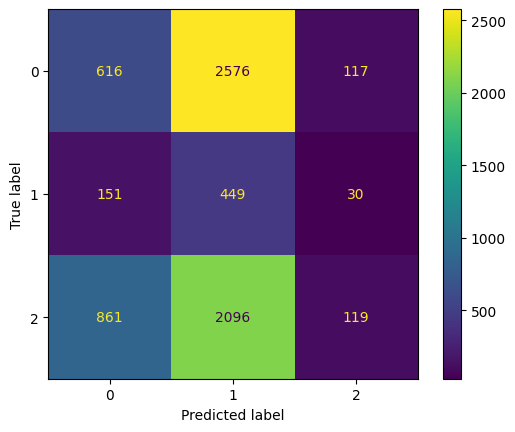

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
torch.manual_seed(42)

epochs = 70

train_dataset = TensorDataset(X_train_torch, arousal_train_torch)
test_dataset = TensorDataset(X_test_torch, arousal_test_torch)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler_a)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_loss_list = []
test_loss_list = []
train_acc_list = []
test_acc_list = []
# train_prec_list = []
# test_prec_list = []

for epoch in range(epochs):
  train_loss_epoch = 0
  correct_train = 0
  total_train = 0
  # epoch_precision = 0
  model_0.train()

  # all_preds = []
  # all_labels = []

  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    optimizer.zero_grad()
    logits = model_0(X_batch)
    loss = loss_fn(logits, y_batch)
    loss.backward()
    optimizer.step()

    train_loss_epoch += loss.item()
    pred = torch.argmax(logits, dim=1)
    correct_train += (pred == y_batch).sum().item()
    total_train += y_batch.size(0)
    # all_preds.append(pred.cpu())
    # all_labels.append(y_batch.cpu())

  train_loss_epoch /= len(train_loader)
  train_loss_list.append(train_loss_epoch)
  train_acc_epoch = 100 * correct_train/total_train
  train_acc_list.append(train_acc_epoch)
  # all_preds = torch.cat(all_preds)
  # all_labels = torch.cat(all_labels)
  # precision = precision_score(all_labels, all_preds, average='macro')
  # train_prec_list.append(precision)

  # ===下面是test=== #

  y_true = []
  y_pred = []

  model_0.eval()
  with torch.inference_mode():
    test_loss_epoch = 0
    correct_test = 0
    total_test = 0
    for X_test_batch, y_test_batch in test_loader:
      X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)

      test_logits = model_0(X_test_batch)
      test_pred = torch.argmax(test_logits, dim=1)
      test_loss = loss_fn(test_logits, y_test_batch)
      test_loss_epoch += test_loss.item()
      correct_test += (test_pred==y_test_batch).sum().item()
      total_test += y_test_batch.size(0)

      y_true.extend(y_test_batch.cpu().numpy())
      y_pred.extend(test_pred.cpu().numpy())

  test_loss_epoch /= len(test_loader)
  test_loss_list.append(test_loss_epoch)
  test_acc_epoch = 100*correct_test/total_test
  test_acc_list.append(test_acc_epoch)
  # test_labels = torch.cat(y_true)
  # test_preds = torch.cat(y_pred)
  # test_precision = precision_score(test_labels, test_preds, average="macro")
  # test_prec_list.append(test_precision)



  if ((epoch+1) % 10 == 0):
      # precision *= 100
      # test_precision *= 100
      print(f"Epoch: {epoch+1} | Loss: {train_loss_epoch:.5f}, Accuracy: {train_acc_epoch:.2f}% | Test loss: {test_loss_epoch:.5f}, Test acc: {test_acc_epoch:.2f}%")
      cm = confusion_matrix(y_true, y_pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm)
      disp.plot()
      plt.show()
      plt.pause(10)
      plt.close()

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(27, 5))
axes[0].plot(range(1, len(train_loss_list)+1), train_loss_list, label='Train Loss', marker='o')
axes[0].plot(range(1, len(test_loss_list)+1), test_loss_list, label='Test Loss', marker='x')
axes[1].plot(range(1, len(train_acc_list)+1), train_acc_list, label='Train Accuracy', marker='o')
axes[1].plot(range(1, len(test_acc_list)+1), test_acc_list, label='Test Accuracy', marker='x')
# axes[1].plot(range(1, len(train_prec_list)+1), train_prec_list[0], label='Train Accuracy class 0', marker='o', color="blue")
# axes[1].plot(range(1, len(test_prec_list)+1), test_prec_list[0], label='Test Accuracy class 0', marker='x', color="blue")
# axes[1].plot(range(1, len(train_prec_list)+1), train_prec_list[1], label='Train Accuracy class 1', marker='o', color="orange")
# axes[1].plot(range(1, len(test_prec_list)+1), test_prec_list[1], label='Test Accuracy class 1', marker='x', color="orange")
# axes[1].plot(range(1, len(train_prec_list)+1), train_prec_list[2], label='Train Accuracy class 2', marker='o', color="red")
# axes[1].plot(range(1, len(test_prec_list)+1), test_prec_list[2], label='Test Accuracy class 2', marker='x', color="red")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[2], colorbar=True)
axes[0].legend()
axes[1].legend()
axes[0].grid(True)
axes[1].grid(True)
plt.show()